# 04.5 - Komparasi Klasifikasi: QLDE vs Standard K-Means (dan Metaheuristik Lain)

**Tujuan Analisis:**
Tahap ini adalah pembuktian akhir untuk melihat algoritma *clustering* mana yang menghasilkan segmentasi pelanggan yang paling terstruktur dan mudah diprediksi oleh AI. Kita akan mengadu metode dari paper referensi (**QLDE**) melawan *baseline* kelompok kita (**Standard**), beserta metode metaheuristik lainnya.

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


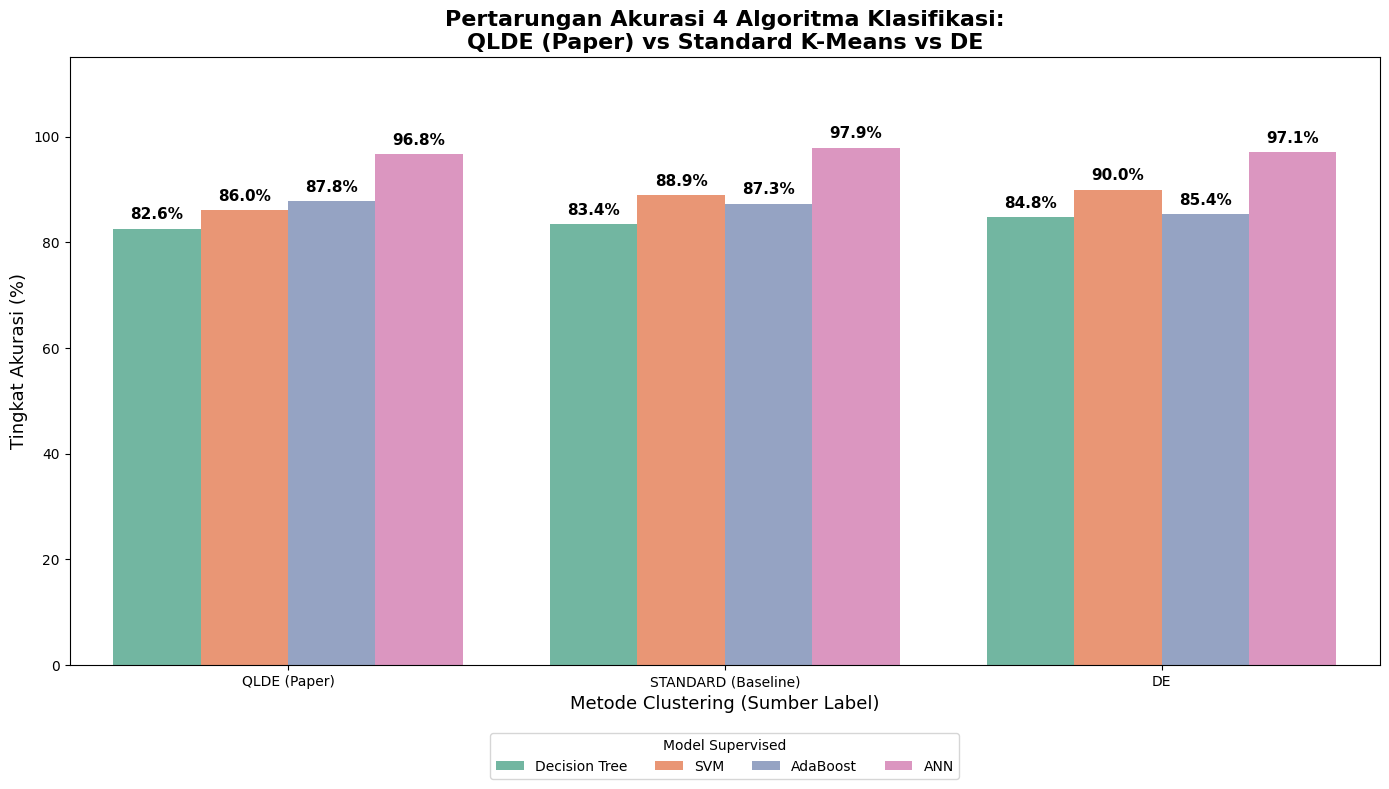

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Daftar semua file hasil clustering di folder Labeled
file_datasets = {
    'QLDE (Paper)': '../data/Labeled/hasildata_kmeans-qlde.csv',
    'STANDARD (Baseline)': '../data/Labeled/hasildata_kmeans-standard.csv',
    'DE': '../data/Labeled/hasildata_kmeans-de.csv'
}

data_hasil = []

# 2. Looping pengujian ke semua dataset
for nama_metode, filepath in file_datasets.items():
    if not os.path.exists(filepath):
        print(f"File {filepath} tidak ditemukan. Lewati...")
        continue
        
    df = pd.read_csv(filepath)
    fitur = [f'Var{i}' for i in range(1, 12)]
    X = df[fitur]
    y = df['Cluster']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Standarisasi data secara penuh untuk ANN
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # --- A. Prediksi Decision Tree ---
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
    model_dt.fit(X_train, y_train)
    akurasi_dt = accuracy_score(y_test, model_dt.predict(X_test))
    
    data_hasil.append({'Sumber Label': nama_metode, 'Algoritma': 'Decision Tree', 'Akurasi': akurasi_dt * 100})
    
    # --- B. Prediksi SVM ---
    # Menjaga efisiensi waktu komputasi (mencegah delay) dengan batas 2000 sampel
    X_train_svm, y_train_svm = X_train[:2000], y_train[:2000]
    scaler_svm = StandardScaler()
    X_train_scaled_svm = scaler_svm.fit_transform(X_train_svm)
    X_test_scaled_svm = scaler_svm.transform(X_test)
    
    model_svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    model_svm.fit(X_train_scaled_svm, y_train_svm)
    akurasi_svm = accuracy_score(y_test, model_svm.predict(X_test_scaled_svm))
    
    data_hasil.append({'Sumber Label': nama_metode, 'Algoritma': 'SVM', 'Akurasi': akurasi_svm * 100})

    # --- C. Prediksi AdaBoost ---
    model_ada = AdaBoostClassifier(random_state=42)
    model_ada.fit(X_train, y_train)
    akurasi_ada = accuracy_score(y_test, model_ada.predict(X_test))
    
    data_hasil.append({'Sumber Label': nama_metode, 'Algoritma': 'AdaBoost', 'Akurasi': akurasi_ada * 100})

    # --- D. Prediksi ANN ---
    model_ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    model_ann.fit(X_train_scaled, y_train)
    akurasi_ann = accuracy_score(y_test, model_ann.predict(X_test_scaled))
    
    data_hasil.append({'Sumber Label': nama_metode, 'Algoritma': 'ANN', 'Akurasi': akurasi_ann * 100})

# ==========================================
# 3. VISUALISASI HASIL (Bar Chart 4 Algoritma)
# ==========================================
df_hasil = pd.DataFrame(data_hasil)

# Mengatur ukuran kanvas lebih lebar agar 4 batang per kelompok tidak berdesakan
plt.figure(figsize=(14, 8))

grafik = sns.barplot(
    data=df_hasil, 
    x='Sumber Label', 
    y='Akurasi', 
    hue='Algoritma',
    palette='Set2' # Menggunakan Set2 agar 4 warnanya kontras dan lembut di mata
)

plt.title('Pertarungan Akurasi 4 Algoritma Klasifikasi:\nQLDE (Paper) vs Standard K-Means vs DE', 
          fontsize=16, fontweight='bold')
plt.xlabel('Metode Clustering (Sumber Label)', fontsize=13)
plt.ylabel('Tingkat Akurasi (%)', fontsize=13)

# Menaikkan batas Y agar angka di atas batang tertinggi tidak terpotong
plt.ylim(0, 115) 

# Memindahkan posisi legend (keterangan warna) agar tidak menutupi batang grafik
plt.legend(title='Model Supervised', loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=4)

# Menampilkan angka persentase tepat di atas pucuk batang grafik
for p in grafik.patches:
    if p.get_height() > 0: # Pastikan batangnya memiliki nilai
        grafik.annotate(f"{p.get_height():.1f}%", 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 10), 
                       textcoords='offset points',
                       fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import time
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Daftar semua file dataset hasil clustering
file_datasets = {
    'QLDE (Paper)': '../data/Labeled/hasildata_kmeans-qlde.csv',
    'STANDARD (Baseline)': '../data/Labeled/hasildata_kmeans-standard.csv',
    'DE': '../data/Labeled/hasildata_kmeans-de.csv'
}

# Siapkan penampung untuk tabel hasil
tabel_hasil = []

# 2. Looping ke seluruh dataset
for nama_metode, filepath in file_datasets.items():
    if not os.path.exists(filepath):
        print(f"File {filepath} tidak ditemukan. Lewati...")
        continue
        
    df = pd.read_csv(filepath)
    fitur = [f'Var{i}' for i in range(1, 12)]
    X = df[fitur]
    y = df['Cluster']
    
    # Membagi Data (Seluruh data digunakan untuk DT)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # ==========================================
    # A. Evaluasi Decision Tree (100% DATA KESELURUHAN)
    # ==========================================
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
    
    mulai_dt = time.time()
    val_acc_dt = cross_val_score(model_dt, X_train, y_train, cv=5).mean() * 100
    model_dt.fit(X_train, y_train)
    test_acc_dt = accuracy_score(y_test, model_dt.predict(X_test)) * 100
    selesai_dt = time.time()
    
    tabel_hasil.append({
        'Dataset': nama_metode,
        'Method': 'Decision Tree (DT)',
        'Validation Mean Accuracy (%)': round(val_acc_dt, 2),
        'Test Set Accuracy (%)': round(test_acc_dt, 2),
        'Time(second)': round(selesai_dt - mulai_dt, 4)
    })
    
    # ==========================================
    # B. Evaluasi Kernel SVM (BATAS AMAN 2000 DATA)
    # ==========================================
    # Mempertahankan batas 2000 sampel untuk mencegah processing delays / crash
    X_train_svm, y_train_svm = X_train[:2000], y_train[:2000]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_svm)
    X_test_scaled = scaler.transform(X_test)
    
    model_svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    
    mulai_svm = time.time()
    val_acc_svm = cross_val_score(model_svm, X_train_scaled, y_train_svm, cv=5).mean() * 100
    model_svm.fit(X_train_scaled, y_train_svm)
    test_acc_svm = accuracy_score(y_test, model_svm.predict(X_test_scaled)) * 100
    selesai_svm = time.time()
    
    tabel_hasil.append({
        'Dataset': nama_metode,
        'Method': 'Kernel SVM (KSVM)',
        'Validation Mean Accuracy (%)': round(val_acc_svm, 2),
        'Test Set Accuracy (%)': round(test_acc_svm, 2),
        'Time(second)': round(selesai_svm - mulai_svm, 4)
    })

# ==========================================
# 3. CETAK HASIL SEBAGAI TABEL
# ==========================================
df_paper_metrics_all = pd.DataFrame(tabel_hasil)

# Menampilkan tabel komparasi akhir
df_paper_metrics_all

,Dataset,Method,Validation Mean Accuracy (%),Test Set Accuracy (%),Time(second)
0,QLDE (Paper),Decision Tree (DT),82.76,82.58,0.0416
1,QLDE (Paper),Kernel SVM (KSVM),86.90,86.04,0.1831
2,STANDARD (Baseline),Decision Tree (DT),84.75,83.39,0.0402
3,STANDARD (Baseline),Kernel SVM (KSVM),89.70,88.93,0.1599
4,DE,Decision Tree (DT),85.06,84.78,0.0386
5,DE,Kernel SVM (KSVM),90.30,89.97,0.1568


In [5]:
import pandas as pd
import time
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Daftar dataset yang difokuskan (QLDE, Standard, DE)
file_datasets = {
    'QLDE (Paper)': '../data/Labeled/hasildata_kmeans-qlde.csv',
    'STANDARD (Baseline)': '../data/Labeled/hasildata_kmeans-standard.csv',
    'DE': '../data/Labeled/hasildata_kmeans-de.csv'
}

tabel_hasil = []

# 2. Looping ke dataset yang dipilih
for nama_metode, filepath in file_datasets.items():
    if not os.path.exists(filepath):
        print(f"File {filepath} tidak ditemukan. Lewati...")
        continue
        
    df = pd.read_csv(filepath)
    fitur = [f'Var{i}' for i in range(1, 12)]
    X = df[fitur]
    y = df['Cluster']
    
    # Membagi Data 80:20 (Menggunakan seluruh baris data)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Scaling seluruh data (100% baris) untuk algoritma yang membutuhkan standarisasi seperti ANN
    scaler_full = StandardScaler()
    X_train_scaled_full = scaler_full.fit_transform(X_train)
    X_test_scaled_full = scaler_full.transform(X_test)
    
    # ==========================================
    # 1. Evaluasi Decision Tree (DT)
    # ==========================================
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
    
    mulai_dt = time.time()
    val_acc_dt = cross_val_score(model_dt, X_train, y_train, cv=5).mean() * 100
    model_dt.fit(X_train, y_train)
    test_acc_dt = accuracy_score(y_test, model_dt.predict(X_test)) * 100
    selesai_dt = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'Decision Tree (DT)', 
                        'Validation Mean Accuracy (%)': round(val_acc_dt, 2), 
                        'Test Set Accuracy (%)': round(test_acc_dt, 2), 
                        'Time(second)': round(selesai_dt - mulai_dt, 4)})
    
    # ==========================================
    # 2. Evaluasi Kernel SVM (KSVM)
    # ==========================================
    X_train_svm, y_train_svm = X_train[:2000], y_train[:2000]
    
    scaler_svm = StandardScaler()
    X_train_scaled_svm = scaler_svm.fit_transform(X_train_svm)
    X_test_scaled_svm = scaler_svm.transform(X_test)
    
    model_svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    
    mulai_svm = time.time()
    val_acc_svm = cross_val_score(model_svm, X_train_scaled_svm, y_train_svm, cv=5).mean() * 100
    model_svm.fit(X_train_scaled_svm, y_train_svm)
    test_acc_svm = accuracy_score(y_test, model_svm.predict(X_test_scaled_svm)) * 100
    selesai_svm = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'Kernel SVM (KSVM)', 
                        'Validation Mean Accuracy (%)': round(val_acc_svm, 2), 
                        'Test Set Accuracy (%)': round(test_acc_svm, 2), 
                        'Time(second)': round(selesai_svm - mulai_svm, 4)})

    # ==========================================
    # 3. Evaluasi AdaBoost
    # ==========================================
    model_ada = AdaBoostClassifier(random_state=42)
    
    mulai_ada = time.time()
    val_acc_ada = cross_val_score(model_ada, X_train, y_train, cv=5).mean() * 100
    model_ada.fit(X_train, y_train)
    test_acc_ada = accuracy_score(y_test, model_ada.predict(X_test)) * 100
    selesai_ada = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'AdaBoost', 
                        'Validation Mean Accuracy (%)': round(val_acc_ada, 2), 
                        'Test Set Accuracy (%)': round(test_acc_ada, 2), 
                        'Time(second)': round(selesai_ada - mulai_ada, 4)})

    # ==========================================
    # 4. Evaluasi Artificial Neural Network (ANN)
    # ==========================================
    model_ann = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
    
    mulai_ann = time.time()
    val_acc_ann = cross_val_score(model_ann, X_train_scaled_full, y_train, cv=5).mean() * 100
    model_ann.fit(X_train_scaled_full, y_train)
    test_acc_ann = accuracy_score(y_test, model_ann.predict(X_test_scaled_full)) * 100
    selesai_ann = time.time()
    
    tabel_hasil.append({'Dataset': nama_metode, 'Method': 'Artificial Neural Network (ANN)', 
                        'Validation Mean Accuracy (%)': round(val_acc_ann, 2), 
                        'Test Set Accuracy (%)': round(test_acc_ann, 2), 
                        'Time(second)': round(selesai_ann - mulai_ann, 4)})

# ==========================================
# CETAK HASIL SEBAGAI TABEL
# ==========================================
df_paper_metrics_all = pd.DataFrame(tabel_hasil)

# Mengurutkan tabel agar rapi berdasarkan Dataset lalu Metode
df_paper_metrics_all = df_paper_metrics_all.sort_values(by=['Dataset', 'Method']).reset_index(drop=True)

# Menampilkan tabel
df_paper_metrics_all

c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimiza

,Dataset,Method,Validation Mean Accuracy (%),Test Set Accuracy (%),Time(second)
0,DE,AdaBoost,86.25,85.35,0.7395
1,DE,Artificial Neural Network (ANN),96.71,97.12,14.0380
2,DE,Decision Tree (DT),85.06,84.78,0.0439
3,DE,Kernel SVM (KSVM),90.30,89.97,0.1922
4,QLDE (Paper),AdaBoost,87.74,87.77,0.7650
5,QLDE (Paper),Artificial Neural Network (ANN),96.48,96.77,14.0172
6,QLDE (Paper),Decision Tree (DT),82.76,82.58,0.0562
7,QLDE (Paper),Kernel SVM (KSVM),86.90,86.04,0.2094
8,STANDARD (Baseline),AdaBoost,85.67,87.31,0.7427
9,STANDARD (Baseline),Artificial Neural Network (ANN),96.86,97.92,13.7391
